In [7]:
import pandas as pd
import numpy as np

# testi

# uusi muutos

In [18]:
df = pd.read_csv("census.csv")
df = df.set_index(["STNAME", "CTYNAME"])
df

SUMLEV  REGION  DIVISION  STATE  COUNTY  \
STNAME  CTYNAME                                                      
Alabama Alabama                40       3         6      1       0   
        Autauga County         50       3         6      1       1   
        Baldwin County         50       3         6      1       3   
        Barbour County         50       3         6      1       5   
        Bibb County            50       3         6      1       7   
...                           ...     ...       ...    ...     ...   
Wyoming Sweetwater County      50       4         8     56      37   
        Teton County           50       4         8     56      39   
        Uinta County           50       4         8     56      41   
        Washakie County        50       4         8     56      43   
        Weston County          50       4         8     56      45   

                           CENSUS2010POP  ESTIMATESBASE2010  POPESTIMATE2010  \
STNAME  CTYNAME                                                                
Alabama Alabama                  4779736            4780127          4785161   
        Autauga County             54571              54571            54660   
        Baldwin County            182265             182265           183193   
        Barbour County             27457              27457            27341   
        Bibb County                22915              22919            22861   
...                                  ...                ...              ...   
Wyoming Sweetwater County          43806              43806            43593   
        Teton County               21294              21294            21297   
        Uinta County               21118              21118            21102   
        Washakie County             8533               8533             8545   
        Weston County               7208               7208             7181   

                           POPESTIMATE2011  POPESTIMATE2012  ...  \
STNAME  CTYNAME                                              ...   
Alabama Alabama                    4801108          4816089  ...   
        Autauga County               55253            55175  ...   
        Baldwin County              186659           190396  ...   
        Barbour County               27226            27159  ...   
        Bibb County                  22733            22642  ...   
...                                    ...              ...  ...   
Wyoming Sweetwater County            44041            45104  ...   
        Teton County                 21482            21697  ...   
        Uinta County                 20912            20989  ...   
        Washakie County               8469             8443  ...   
        Weston County                 7114             7065  ...   

                           RDOMESTICMIG2011  RDOMESTICMIG2012  \
STNAME  CTYNAME                                                 
Alabama Alabama                    0.002295         -0.193196   
        Autauga County             7.242091         -2.915927   
        Baldwin County            14.832960         17.647293   
        Barbour County            -4.728132         -2.500690   
        Bibb County               -5.527043         -5.068871   
...                                     ...               ...   
Wyoming Sweetwater County          1.072643         16.243199   
        Teton County              -1.589565          0.972695   
        Uinta County             -17.755986         -4.916350   
        Washakie County          -11.637475         -0.827815   
        Weston County            -11.752361         -8.040059   

                           RDOMESTICMIG2013  RDOMESTICMIG2014  \
STNAME  CTYNAME                                                 
Alabama Alabama                    0.381066          0.582002   
        Autauga County            -3.012349          2.265971   
        Baldwin County            21.845705         19.243287   
        Barbour Cou

In [ ]:
df.groupby("STNAME").aggregate({"CENSUS2010POP": np.sum})

In [ ]:
df.groupby("STNAME").aggregate({"CENSUS2010POP": [np.sum, np.average, np.std, np.size]})
df.columns.sort_values()


In [1]:
# Boolean Mask

df_new = df.groupby("STNAME").aggregate({"CENSUS2010POP": [np.sum, np.average, np.std, np.size], "POPESTIMATE2015": np.sum})
df_new["Substraction"] = df_new["POPESTIMATE2015", "sum"] - df_new["CENSUS2010POP", "sum"]
(df_new["Substraction"] < 0).sum()
df_new[(df_new["Substraction"] < 0)]



NameError: name 'df' is not defined

In [ ]:
df.groupby("STNAME").aggregate({"CENSUS2010POP": np.sum})

In [40]:
import scipy as sc
import scipy.stats as stats

stats.pearsonr(df_new["CENSUS2010POP", "average"], df_new["Substraction"])


(0.3958947415570175, 0.004031652363542351)

In [44]:

stats.pearsonr(df_new["CENSUS2010POP", "std"], df_new["Substraction"])

(0.6943967424301536, 1.5905060726210125e-08)

In [54]:
 def classification_function(state_name):
    if df_new.loc[state_name]["CENSUS2010POP", "sum"] < 5000000:
        return "small"
    elif df_new.loc[state_name]["CENSUS2010POP", "sum"] < 15000000:
        return "medium"
    else:
        return "large"

classification_function("Alabama")
 

'medium'

In [ ]:
df_new

In [ ]:
# df_new.groupby(classification_function).groups  #.aggregate({"Substraction": np.average})

group_states = df_new.groupby(classification_function).aggregate({"Substraction": np.average})
for name, group in group_states:
    print(name)
    print(group["Substraction"])

In [ ]:
group_states = df_new.groupby(classification_function).aggregate({"Substraction": np.average})

In [47]:
df_new["Substraction"]

STNAME
Alabama                  158486
Alaska                    56402
Arizona                  872096
Arkansas                 124572
California              3781724
Colorado                 854756
Connecticut               33578
Delaware                  96000
District of Columbia     141010
Florida                 2939924
Georgia                 1054414
Hawaii                   142604
Idaho                    174696
Illinois                  58726
Indiana                  271756
Iowa                     155088
Kansas                   117046
Kentucky                 171450
Louisiana                274704
Maine                      1934
Maryland                 465698
Massachusetts            493586
Michigan                  77872
Minnesota                371338
Mississippi               50072
Missouri                 189490
Montana                   87068
Nebraska                 139698
Nevada                   380588
New Hampshire             28276
New Jersey               332238
N

<AxesSubplot:xlabel='STNAME'>

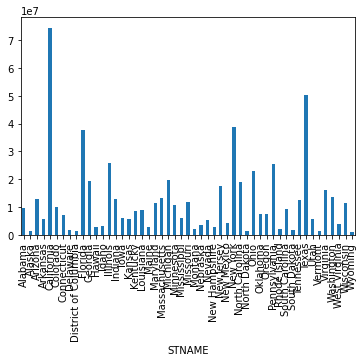

In [62]:
df_new["CENSUS2010POP", "sum"].plot.bar()

In [64]:
df_new["CENSUS2010POP", "sum"].sort_values(ascending=False)

STNAME
California              74507912
Texas                   50291122
New York                38756204
Florida                 37602620
Illinois                25661264
Pennsylvania            25404758
Ohio                    23073008
Michigan                19767280
Georgia                 19375306
North Carolina          19070966
New Jersey              17583788
Virginia                15995826
Washington              13449080
Massachusetts           13095258
Indiana                 12967604
Arizona                 12784034
Tennessee               12692210
Missouri                11977854
Maryland                11547104
Wisconsin               11373972
Minnesota               10607850
Colorado                10058392
Alabama                  9559472
South Carolina           9250728
Louisiana                9066744
Kentucky                 8678734
Oregon                   7662148
Oklahoma                 7502702
Connecticut              7148194
Iowa                     6092710
Mis